In [1]:
import pandas as pd
import random
import csv
import numpy as np
from datetime import datetime
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from transformers import pipeline
from flask import Flask, request, jsonify
from pyngrok import ngrok
from threading import Thread
import requests
print("✅ Imports OK")


✅ Imports OK


In [2]:
CATALOGO = {
    "dev": {
        "nombre": "Ruta DEV — IA aplicada al desarrollo",
        "talleres": [
            {"id": "T01", "nombre": "Engram: memoria persistente para tu agente de IA", "nivel": "intermedio", "estado": "disponible"},
            {"id": "T02", "nombre": "Gentle AI: ecosistema completo para agentes", "nivel": "avanzado", "estado": "disponible"},
            {"id": "D1",  "nombre": "Claude Code desde Cero", "nivel": "principiante", "estado": "proximamente"},
            {"id": "D2",  "nombre": "MCP Servers: construí tus propias herramientas", "nivel": "avanzado", "estado": "proximamente"},
            {"id": "D3",  "nombre": "RAG y memoria semántica con Engram + Obsidian", "nivel": "intermedio", "estado": "proximamente"},
        ]
    },
    "emprendedor": {
        "nombre": "Ruta EMPRENDEDOR — Del propósito al producto",
        "talleres": [
            {"id": "T03", "nombre": "Del Sueño a la Convocatoria", "nivel": "principiante", "estado": "disponible"},
            {"id": "T07", "nombre": "KAIA: Sistema Operativo Creativo", "nivel": "intermedio", "estado": "disponible"},
            {"id": "T09", "nombre": "Blockchain sin el Hype", "nivel": "intermedio", "estado": "disponible"},
            {"id": "E1",  "nombre": "IA para Marketing y Ventas en PyMEs", "nivel": "principiante", "estado": "proximamente"},
            {"id": "E2",  "nombre": "Prompt Engineering Estratégico para Líderes", "nivel": "intermedio", "estado": "proximamente"},
            {"id": "E3",  "nombre": "Automatización con n8n + IA", "nivel": "intermedio", "estado": "proximamente"},
        ]
    },
    "profesional": {
        "nombre": "Ruta PROFESIONAL — Productividad aumentada",
        "talleres": [
            {"id": "T05", "nombre": "Cerebro Aumentado: Obsidian + Claude + Engram", "nivel": "intermedio", "estado": "disponible"},
            {"id": "P1",  "nombre": "IA para Investigación y Escritura Académica", "nivel": "principiante", "estado": "proximamente"},
            {"id": "P2",  "nombre": "Análisis de Datos sin Código (con IA)", "nivel": "principiante", "estado": "proximamente"},
            {"id": "P3",  "nombre": "IA para Abogados Colombianos", "nivel": "intermedio", "estado": "proximamente"},
        ]
    },
    "bienestar": {
        "nombre": "Ruta BIENESTAR — Cuidado integral",
        "talleres": [
            {"id": "T04", "nombre": "Sistema de Auto-Protección Mental", "nivel": "abierto", "estado": "disponible"},
            {"id": "T06", "nombre": "Mapa Personal de Recuperación (Depresión)", "nivel": "clinico", "estado": "disponible"},
            {"id": "B1",  "nombre": "IA y Salud Mental — Usos responsables", "nivel": "abierto", "estado": "proximamente"},
            {"id": "B2",  "nombre": "Productividad Consciente — KAIA aplicado al trabajo", "nivel": "intermedio", "estado": "proximamente"},
        ]
    },
    "estrategica": {
        "nombre": "Ruta ESTRATÉGICA — Gobernanza y liderazgo",
        "talleres": [
            {"id": "T08", "nombre": "AI Regulation & Compliance", "nivel": "estrategico", "estado": "disponible"},
            {"id": "S1",  "nombre": "Diagnóstico de Madurez IA organizacional", "nivel": "estrategico", "estado": "proximamente"},
            {"id": "S2",  "nombre": "Liderazgo en la era de la IA (C-level)", "nivel": "estrategico", "estado": "proximamente"},
            {"id": "S3",  "nombre": "IA Ética para Equipos LATAM", "nivel": "estrategico", "estado": "proximamente"},
        ]
    }
}

total = sum(len(r["talleres"]) for r in CATALOGO.values())
print(f"✅ Catálogo cargado: {total} talleres en {len(CATALOGO)} rutas")

✅ Catálogo cargado: 23 talleres en 5 rutas


In [3]:
random.seed(42)

PERFILES = ["dev", "emprendedor", "profesional", "persona_proceso", "lider_organizacional"]
PESOS_PERFIL = [15, 30, 25, 15, 15]

OBJETIVOS = ["aprender_tecnico", "lanzar_proyecto", "productividad", "bienestar", "gobernanza_ia"]

NIVELES = ["principiante", "intermedio", "avanzado"]
PESOS_NIVEL = [60, 30, 10]

AREAS = ["ia_general", "ia_negocio", "salud_mental", "blockchain", "compliance", "datos"]

def asignar_ruta(perfil, objetivo):
    if perfil == "dev":
        return "dev"
    if perfil == "lider_organizacional" or objetivo == "gobernanza_ia":
        return "estrategica"
    if perfil == "persona_proceso" or objetivo == "bienestar":
        return "bienestar"
    if perfil == "emprendedor" or objetivo == "lanzar_proyecto":
        return "emprendedor"
    return "profesional"

data = []
for i in range(500):
    perfil = random.choices(PERFILES, weights=PESOS_PERFIL, k=1)[0]
    objetivo = random.choice(OBJETIVOS)
    nivel = random.choices(NIVELES, weights=PESOS_NIVEL, k=1)[0]
    area = random.choice(AREAS)
    ruta = asignar_ruta(perfil, objetivo)
    data.append([perfil, objetivo, nivel, area, ruta])

df = pd.DataFrame(data, columns=["perfil", "objetivo", "nivel", "area_interes", "ruta"])
df.to_csv("dataset_sdih.csv", index=False)

print(f"✅ Dataset generado: {len(df)} registros")
print("\nDistribución de rutas:")
print(df["ruta"].value_counts())
df.head(10)

✅ Dataset generado: 500 registros

Distribución de rutas:
ruta
estrategica    154
bienestar      112
emprendedor    103
dev             75
profesional     56
Name: count, dtype: int64


,perfil,objetivo,nivel,area_interes,ruta
0,profesional,aprender_tecnico,intermedio,ia_negocio,profesional
1,emprendedor,aprender_tecnico,intermedio,compliance,emprendedor
2,dev,bienestar,principiante,ia_general,dev
3,emprendedor,gobernanza_ia,intermedio,compliance,estrategica
4,emprendedor,gobernanza_ia,principiante,blockchain,estrategica
5,profesional,aprender_tecnico,intermedio,ia_negocio,profesional
6,profesional,productividad,principiante,ia_negocio,profesional
7,lider_organizacional,productividad,principiante,blockchain,estrategica
8,dev,productividad,intermedio,ia_general,dev
9,persona_proceso,gobernanza_ia,principiante,blockchain,estrategica


In [4]:
le_perfil = LabelEncoder()
le_objetivo = LabelEncoder()
le_nivel = LabelEncoder()
le_area = LabelEncoder()
le_ruta = LabelEncoder()

df_enc = df.copy()
df_enc["perfil"] = le_perfil.fit_transform(df_enc["perfil"])
df_enc["objetivo"] = le_objetivo.fit_transform(df_enc["objetivo"])
df_enc["nivel"] = le_nivel.fit_transform(df_enc["nivel"])
df_enc["area_interes"] = le_area.fit_transform(df_enc["area_interes"])
df_enc["ruta"] = le_ruta.fit_transform(df_enc["ruta"])

X = df_enc[["perfil", "objetivo", "nivel", "area_interes"]]
y = df_enc["ruta"]

print("✅ Preprocesamiento completo")
print("Clases (rutas):", list(le_ruta.classes_))

✅ Preprocesamiento completo
Clases (rutas): ['bienestar', 'dev', 'emprendedor', 'estrategica', 'profesional']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# multi_class ya no se especifica — sklearn moderno lo detecta solo
modelo = LogisticRegression(max_iter=1000, solver='lbfgs')
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)
print("✅ Modelo entrenado\n")
print(classification_report(y_test, y_pred, target_names=le_ruta.classes_))

✅ Modelo entrenado

              precision    recall  f1-score   support

   bienestar       0.58      0.50      0.54        22
         dev       1.00      1.00      1.00        15
 emprendedor       0.46      0.29      0.35        21
 estrategica       0.49      0.61      0.54        31
 profesional       0.50      0.64      0.56        11

    accuracy                           0.58       100
   macro avg       0.61      0.61      0.60       100
weighted avg       0.58      0.58      0.57       100



Coeficientes del modelo (peso de cada variable por ruta):

             perfil  objetivo  nivel  area_interes
bienestar     0.973    -0.358  0.105        -0.166
dev          -5.023     0.077 -0.134         0.025
emprendedor   0.245     0.273 -0.101         0.199
estrategica   0.628    -0.050 -0.009        -0.055
profesional   3.177     0.058  0.139        -0.002


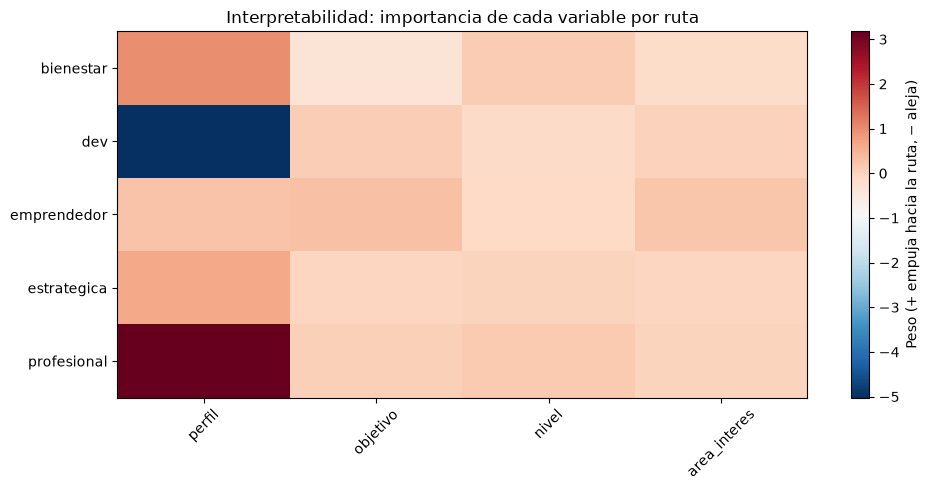

In [6]:
variables = ["perfil", "objetivo", "nivel", "area_interes"]
print("Coeficientes del modelo (peso de cada variable por ruta):\n")

coef_df = pd.DataFrame(
    modelo.coef_,
    columns=variables,
    index=le_ruta.classes_
)
print(coef_df.round(3))

plt.figure(figsize=(10, 5))
plt.imshow(modelo.coef_, cmap='RdBu_r', aspect='auto')
plt.colorbar(label='Peso (+ empuja hacia la ruta, − aleja)')
plt.yticks(range(len(le_ruta.classes_)), le_ruta.classes_)
plt.xticks(range(len(variables)), variables, rotation=45)
plt.title("Interpretabilidad: importancia de cada variable por ruta")
plt.tight_layout()
plt.show()

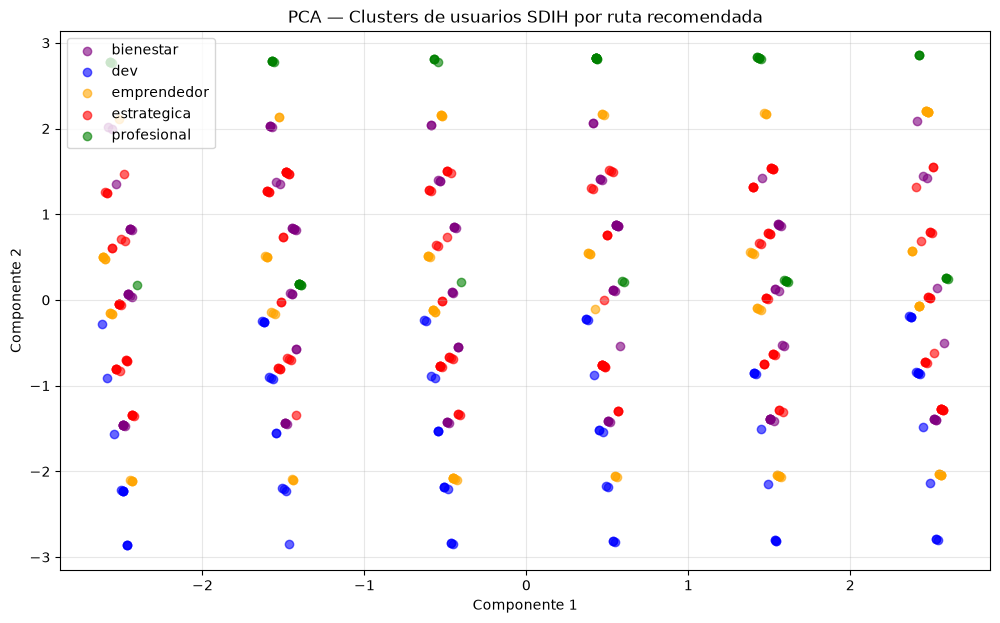

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(12, 7))
colores = {'dev': 'blue', 'emprendedor': 'orange', 'profesional': 'green', 'bienestar': 'purple', 'estrategica': 'red'}

for ruta_nombre in le_ruta.classes_:
    mask = df["ruta"] == ruta_nombre
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colores[ruta_nombre], label=ruta_nombre, alpha=0.6)

plt.title("PCA — Clusters de usuarios SDIH por ruta recomendada")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
import os
from dotenv import load_dotenv

# Carga las variables desde .env
load_dotenv()

HF_TOKEN = os.getenv("HF_TOKEN")
if not HF_TOKEN:
    raise ValueError("⚠️ Falta HF_TOKEN en el archivo .env. Revisá el README.")

from huggingface_hub import InferenceClient

client = InferenceClient(
    model="Qwen/Qwen2.5-7B-Instruct",
    token=HF_TOKEN
)

class ChatbotAPI:
    def __call__(self, prompt, max_new_tokens=200, do_sample=True, temperature=0.7):
        respuesta = client.chat_completion(
            messages=[{"role": "user", "content": prompt}],
            max_tokens=max_new_tokens,
            temperature=temperature
        )
        texto_generado = respuesta.choices[0].message.content
        return [{"generated_text": prompt + "\n" + texto_generado}]

chatbot = ChatbotAPI()
print("✅ Cliente HF Inference API listo")

✅ Cliente HF Inference API listo


In [9]:
def predecir_ruta(perfil, objetivo, nivel, area):
    """Recibe strings, devuelve nombre de la ruta predicha"""
    try:
        p = le_perfil.transform([perfil])[0]
        o = le_objetivo.transform([objetivo])[0]
        n = le_nivel.transform([nivel])[0]
        a = le_area.transform([area])[0]
        pred_num = modelo.predict([[p, o, n, a]])[0]
        return le_ruta.inverse_transform([pred_num])[0]
    except ValueError:
        return "profesional"

print("✅ Función predecir_ruta lista")

✅ Función predecir_ruta lista


In [10]:
LOG_DEMANDA = "log_demanda_talleres.csv"

try:
    with open(LOG_DEMANDA, "x", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["timestamp", "taller_id", "taller_nombre", "ruta", "estado"])
    print(f"✅ Log creado: {LOG_DEMANDA}")
except FileExistsError:
    print(f"ℹ️ Log ya existe: {LOG_DEMANDA}")

def registrar_demanda(taller):
    if taller["estado"] == "proximamente":
        with open(LOG_DEMANDA, "a", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                datetime.now().isoformat(),
                taller["id"],
                taller["nombre"],
                taller.get("ruta", ""),
                taller["estado"]
            ])

ℹ️ Log ya existe: log_demanda_talleres.csv


In [11]:
def interpretar_input(pregunta):
    p = pregunta.lower()
    
    if any(x in p for x in ["dev", "programar", "código", "codigo", "developer", "desarrollador"]):
        perfil = "dev"
    elif any(x in p for x in ["emprend", "negocio", "startup", "lanzar"]):
        perfil = "emprendedor"
    elif any(x in p for x in ["líder", "lider", "ceo", "directiv", "gerent"]):
        perfil = "lider_organizacional"
    elif any(x in p for x in ["ansiedad", "depres", "estrés", "estres", "salud mental", "bienestar"]):
        perfil = "persona_proceso"
    else:
        perfil = "profesional"
    
    if any(x in p for x in ["aprender", "técnico", "tecnico"]):
        objetivo = "aprender_tecnico"
    elif any(x in p for x in ["productiv", "organizar"]):
        objetivo = "productividad"
    elif any(x in p for x in ["compliance", "regulac", "gobernanza", "ley"]):
        objetivo = "gobernanza_ia"
    elif any(x in p for x in ["lanzar", "construir", "crear"]):
        objetivo = "lanzar_proyecto"
    elif any(x in p for x in ["bienestar", "mental", "ansiedad"]):
        objetivo = "bienestar"
    else:
        objetivo = "aprender_tecnico"
    
    if any(x in p for x in ["avanzad", "experto", "años de experiencia"]):
        nivel = "avanzado"
    elif any(x in p for x in ["intermedio", "ya conozco", "ya trabajo"]):
        nivel = "intermedio"
    else:
        nivel = "principiante"
    
    if "blockchain" in p:
        area = "blockchain"
    elif any(x in p for x in ["dato", "data"]):
        area = "datos"
    elif "compliance" in p:
        area = "compliance"
    elif "negocio" in p:
        area = "ia_negocio"
    elif any(x in p for x in ["mental", "salud"]):
        area = "salud_mental"
    else:
        area = "ia_general"
    
    return perfil, objetivo, nivel, area


def seleccionar_talleres(ruta, nivel):
    talleres_ruta = CATALOGO[ruta]["talleres"]
    coinciden = [t for t in talleres_ruta if t["nivel"] == nivel]
    if not coinciden:
        coinciden = talleres_ruta
    return coinciden[:2]


def asesor_sdih(pregunta):
    perfil, objetivo, nivel, area = interpretar_input(pregunta)
    ruta = predecir_ruta(perfil, objetivo, nivel, area)
    talleres_sugeridos = seleccionar_talleres(ruta, nivel)
    
    for t in talleres_sugeridos:
        registrar_demanda({**t, "ruta": ruta})
    
    catalogo_texto = "\n".join([
        f'- "{t["nombre"]}" (nivel {t["nivel"]}) [{"DISPONIBLE ✅" if t["estado"]=="disponible" else "PRÓXIMAMENTE 🔜"}]'
        for t in talleres_sugeridos
    ])
    
    prompt = f"""Eres asesor del Salazar Duke Impact Hub (SDIH), una empresa COLOMBIANA de formación en IA.

Pregunta del usuario: {pregunta}

Perfil detectado: {perfil} | Objetivo: {objetivo} | Nivel: {nivel}
Ruta recomendada: {CATALOGO[ruta]['nombre']}

TALLERES PARA RECOMENDAR (USA EXACTAMENTE ESTOS NOMBRES, NO INVENTES OTROS):
{catalogo_texto}

REGLAS ABSOLUTAS:
1. SOLO podés mencionar los talleres listados arriba con su nombre EXACTO entre comillas.
2. PROHIBIDO inventar nombres de talleres que no estén en la lista.
3. Habla en español colombiano profesional: usá "tú", "tienes", "puedes", "te recomiendo".
4. PROHIBIDO usar "che", "vos", "mate", "oye", "ñero", "parce".
5. Máximo 4 líneas de respuesta total.
6. NO uses asteriscos (**), guiones bajos (_), ni formato Markdown.
7. Si un taller dice PRÓXIMAMENTE, menciónalo y ofrece avisar cuando esté disponible.

Respuesta:"""
    
    out = chatbot(prompt, max_new_tokens=250, do_sample=True, temperature=0.3)
    texto = out[0]["generated_text"].split("Respuesta:")[-1].strip()
    texto = texto.replace("**", "").replace("__", "").replace("*", "")
    return texto

print("✅ Motor asesor_sdih v3 — sin alucinaciones, tono colombiano")

✅ Motor asesor_sdih v3 — sin alucinaciones, tono colombiano


In [12]:
respuesta = asesor_sdih("Soy emprendedora colombiana y quiero lanzar mi negocio usando IA, soy principiante")
print("🤖 RESPUESTA DEL BOT:\n")
print(respuesta)
print("\n📊 --- Demanda registrada ---")
print(pd.read_csv(LOG_DEMANDA))

C:\Users\jsala\anaconda3\envs\sdih_asesor\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


🤖 RESPUESTA DEL BOT:

Tienes que empezar por definir tu propósito y tu sueño para tu negocio. Te recomiendo que asistas al taller "Del Sueño a la Convocatoria" (nivel principiante), que está disponible. Además, cuando esté disponible el taller "IA para Marketing y Ventas en PyMEs" (nivel principiante), también podrías interesarte en él para integrar la IA en tus estrategias.

📊 --- Demanda registrada ---
    2026-06-22T18:29:59.161734  E1  \
0   2026-06-22T18:31:39.207995  E1   
1   2026-06-22T18:34:03.632039  E1   
2   2026-06-22T18:43:18.592801  S1   
3   2026-06-22T20:06:35.724541  B2   
4   2026-06-22T20:18:35.181898  E1   
5   2026-06-22T20:18:40.024288  S1   
6   2026-06-22T20:18:42.711917  B2   
7   2026-06-22T20:22:36.214415  B2   
8   2026-06-22T20:26:59.574219  E1   
9   2026-06-22T20:27:02.901643  S1   
10  2026-06-22T20:29:49.422780  E1   
11  2026-06-22T20:31:09.288627  D1   
12  2026-06-22T20:38:19.557204  E1   
13  2026-06-22T20:39:01.568962  D2   
14  2026-06-22T20:39:2

In [13]:
app = Flask(__name__)

@app.route("/asesor", methods=["POST"])
def asesor_endpoint():
    data = request.json
    pregunta = data.get("mensaje", "")
    respuesta = asesor_sdih(pregunta)
    return jsonify({"respuesta": respuesta})

@app.route("/demanda", methods=["GET"])
def ver_demanda():
    df_log = pd.read_csv(LOG_DEMANDA)
    resumen = df_log["taller_nombre"].value_counts().to_dict()
    return jsonify(resumen)

@app.route("/", methods=["GET"])
def home():
    return "Asesor SDIH activo"

def run_app():
    app.run(port=5000, use_reloader=False)

Thread(target=run_app, daemon=True).start()
print("✅ Flask corriendo en http://localhost:5000")

✅ Flask corriendo en http://localhost:5000
 * Serving Flask app '__main__'


In [14]:
NGROK_AUTHTOKEN = os.getenv("NGROK_AUTHTOKEN")
if not NGROK_AUTHTOKEN:
    raise ValueError("⚠️ Falta NGROK_AUTHTOKEN en .env")

ngrok.set_auth_token(NGROK_AUTHTOKEN)
public_url = ngrok.connect(5000)
print(f"🌐 URL PÚBLICA: {public_url.public_url}")
print(f"📡 Endpoint asesor: {public_url.public_url}/asesor")
print(f"📊 Endpoint demanda: {public_url.public_url}/demanda")

 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit


🌐 URL PÚBLICA: https://extras-cadillac-volley.ngrok-free.dev
📡 Endpoint asesor: https://extras-cadillac-volley.ngrok-free.dev/asesor
📊 Endpoint demanda: https://extras-cadillac-volley.ngrok-free.dev/demanda


In [15]:
url = f"{public_url.public_url}/asesor"
r = requests.post(url, json={"mensaje": "soy líder de una organización colombiana y necesito implementar IA con compliance"})
print("🌐 RESPUESTA DE LA API PÚBLICA:\n")
print(r.json()["respuesta"])

C:\Users\jsala\anaconda3\envs\sdih_asesor\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
127.0.0.1 - - [22/Jun/2026 21:04:47] "POST /asesor HTTP/1.1" 200 -


🌐 RESPUESTA DE LA API PÚBLICA:

Tienes que implementar IA con compliance en tu organización. Te recomiendo comenzar con el taller "AI Regulation & Compliance" (nivel estrategico), que está disponible. Además, cuando esté disponible, te puede ayudar mucho el "Diagnóstico de Madurez IA organizacional". Te mantendré informado sobre su disponibilidad.


In [16]:
import requests
r = requests.post(
    "https://extras-cadillac-volley.ngrok-free.dev/asesor",
    json={"mensaje": "test"}
)
print("Status:", r.status_code)
print("Respuesta:", r.json())

C:\Users\jsala\anaconda3\envs\sdih_asesor\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
127.0.0.1 - - [22/Jun/2026 21:04:49] "POST /asesor HTTP/1.1" 200 -


Status: 200
Respuesta: {'respuesta': 'Te recomiendo los talleres "Sistema de Auto-Protección Mental" y "Mapa Personal de Recuperación (Depresión)". Ambos están disponibles y te ayudarán a mejorar tu bienestar. Si uno de ellos dice próximamente, te aviso cuando esté disponible.'}


In [ ]:
TELEGRAM_TOKEN = os.getenv("TELEGRAM_BOT_TOKEN")
if not TELEGRAM_TOKEN:
    raise ValueError("⚠️ Falta TELEGRAM_BOT_TOKEN en .env")

import nest_asyncio
nest_asyncio.apply()

from telegram import Update
from telegram.ext import Application, MessageHandler, CommandHandler, filters, ContextTypes

async def start(update, context):
    await update.message.reply_text(
        "👋 Hola, soy el Asesor SDIH.\n\n"
        "Tenemos 22 talleres en 5 rutas: Dev, Emprendedor, Profesional, Bienestar y Estratégica.\n\n"
        "Contame: ¿quién sos, qué querés lograr con la IA, y cuál es tu nivel (principiante/intermedio/avanzado)?"
    )

async def responder(update, context):
    user_message = update.message.text
    await update.message.reply_text("⏳ Procesando tu consulta...")
    respuesta = asesor_sdih(user_message)
    await update.message.reply_text(respuesta)

app_tg = Application.builder().token(TELEGRAM_TOKEN).build()
app_tg.add_handler(CommandHandler("start", start))
app_tg.add_handler(MessageHandler(filters.TEXT & ~filters.COMMAND, responder))

print("✅ Bot Telegram conectado (con tokens seguros desde .env)")
print("👉 En Telegram → /start y escribí algo")
print("⚠️ Para parar: Kernel → Interrupt")

app_tg.run_polling()

Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "C:\Users\jsala\anaconda3\envs\sdih_asesor\Lib\asyncio\events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x000002766BE287C0> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "C:\Users\jsala\anaconda3\envs\sdih_asesor\Lib\asyncio\events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x000002766BE287C0> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "C:\Users\jsala\anaconda3\envs\sdih_asesor\Lib\asyncio\events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Cont

✅ Bot Telegram conectado (con tokens seguros desde .env)
👉 En Telegram → /start y escribí algo
⚠️ Para parar: Kernel → Interrupt


Task was destroyed but it is pending!
task: <Task pending name='Task-31' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\jsala\anaconda3\envs\sdih_asesor\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-32' coro=<Kernel.shell_main() running at C:\Users\jsala\anaconda3\envs\sdih_asesor\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\jsala\anaconda3\envs\sdih_asesor\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\jsala\anaconda3\envs\sdih_asesor\Lib\contextlib.py:144: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  next(self.gen)
Task was destroyed but it is pending!
task: <Task pending name='Task-32' coro=<Kernel.shell_main() running at C:\Users\jsala\anaconda3\envs\sdih_asesor\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.__wakeup()]>
Task was destroyed but it is pending!
task: <Task pending name='Task-33' coro=